# 05 — Temporal Validation

Insurance portfolios have inherent temporal structure: earlier policies may behave differently from newer ones due to economic cycles, driver cohort effects, and regulatory changes.  
Random train/test splits **ignore** this structure and can give optimistic AUC estimates.

This notebook benchmarks a random split baseline against walk-forward temporal folds using **IDpol as a time proxy** (lower policy ID ≈ earlier enrollment).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from claims.data import load_fremtpl2, build_claims_dataset, split_dataset, temporal_split
from claims.features import engineer_features
from claims.classification.models import catboost_classifier
from claims.features import NUMERIC_FEATURES, CATEGORICAL_FEATURES, catboost_cat_indices

In [ ]:
from pathlib import Path
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures → {FIG_DIR.resolve()}")

In [3]:
# Load and join the two freMTPL2 tables
print('Loading freMTPL2 from OpenML...')
freq, sev = load_fremtpl2()
df = build_claims_dataset(freq, sev)
df = engineer_features(df)
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Claim rate: {df['HasClaim'].mean():.3%}")


Loading freMTPL2 from OpenML...


Dataset: 678,013 rows, 24 columns
Claim rate: 5.024%


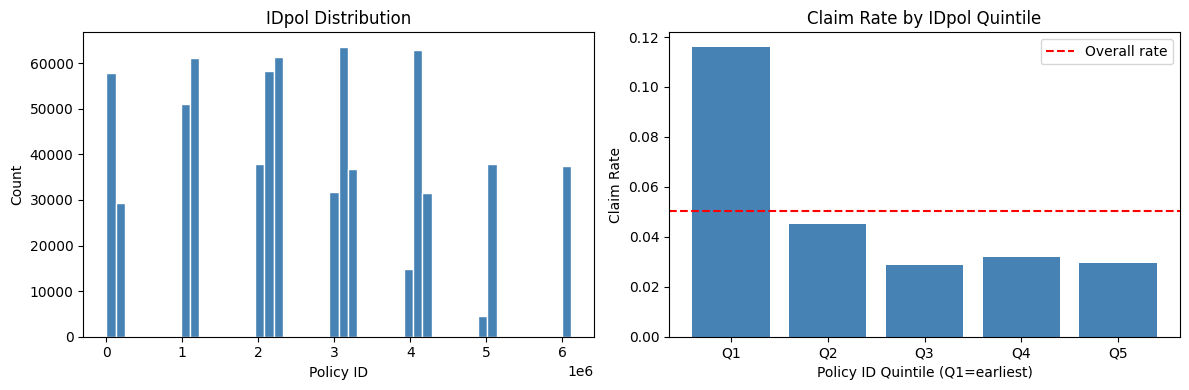

Claim rate by quintile: {'Q1': 0.1161, 'Q2': 0.0452, 'Q3': 0.0286, 'Q4': 0.0317, 'Q5': 0.0295}


In [4]:
# IDpol as time proxy — validate assumption by checking distribution
df['IDpol_num'] = pd.to_numeric(df['IDpol'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['IDpol_num'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('IDpol Distribution')
axes[0].set_xlabel('Policy ID')
axes[0].set_ylabel('Count')

# Claim rate by IDpol quintile — if temporal signal exists, rate should vary
df['IDpol_quintile'] = pd.qcut(df['IDpol_num'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
claim_by_q = df.groupby('IDpol_quintile')['HasClaim'].mean()
axes[1].bar(claim_by_q.index, claim_by_q.values, color='steelblue')
axes[1].set_title('Claim Rate by IDpol Quintile')
axes[1].set_xlabel('Policy ID Quintile (Q1=earliest)')
axes[1].set_ylabel('Claim Rate')
axes[1].axhline(df['HasClaim'].mean(), color='red', linestyle='--', label='Overall rate')
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "05_idpol_distribution.png", bbox_inches="tight", dpi=130)
plt.show()
print("Claim rate by quintile:", claim_by_q.round(4).to_dict())

In [5]:
# Random split baseline — the standard approach
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
CAT_IDX = catboost_cat_indices()

train, test = split_dataset(df, target='HasClaim', random_state=42)

X_tr, y_tr = train[FEATURES].values, train['HasClaim'].values
X_te, y_te = test[FEATURES].values, test['HasClaim'].values

model_baseline = catboost_classifier()
model_baseline.fit(X_tr, y_tr, eval_set=(X_te, y_te), cat_features=CAT_IDX)

baseline_auc = roc_auc_score(y_te, model_baseline.predict_proba(X_te)[:, 1])
print(f"Random split AUC: {baseline_auc:.4f}")

Random split AUC: 0.7105


In [6]:
# Create temporal folds and inspect sizes
N_FOLDS = 3
folds = temporal_split(df, n_folds=N_FOLDS, id_col='IDpol')

print(f"Temporal walk-forward: {N_FOLDS} folds")
print("-" * 45)
for k, (tr_idx, te_idx) in enumerate(folds, 1):
    print(f"Fold {k}: train={len(tr_idx):,}  test={len(te_idx):,}")

Temporal walk-forward: 3 folds
---------------------------------------------
Fold 1: train=169,503  test=169,503
Fold 2: train=339,006  test=169,503
Fold 3: train=508,509  test=169,504


In [7]:
# Train model on each fold and collect AUCs
temporal_aucs = []
for k, (tr_idx, te_idx) in enumerate(folds, 1):
    X_tr = df.iloc[tr_idx][FEATURES].values
    y_tr = df.iloc[tr_idx]['HasClaim'].values
    X_te = df.iloc[te_idx][FEATURES].values
    y_te = df.iloc[te_idx]['HasClaim'].values

    model = catboost_classifier()
    model.fit(X_tr, y_tr, eval_set=(X_te, y_te), cat_features=CAT_IDX)
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    temporal_aucs.append(auc)
    print(f"Fold {k}: AUC = {auc:.4f}")

print(f"\nMean temporal AUC: {np.mean(temporal_aucs):.4f} ± {np.std(temporal_aucs):.4f}")


Fold 1: AUC = 0.6221


Fold 2: AUC = 0.6756


Fold 3: AUC = 0.6475

Mean temporal AUC: 0.6484 ± 0.0218


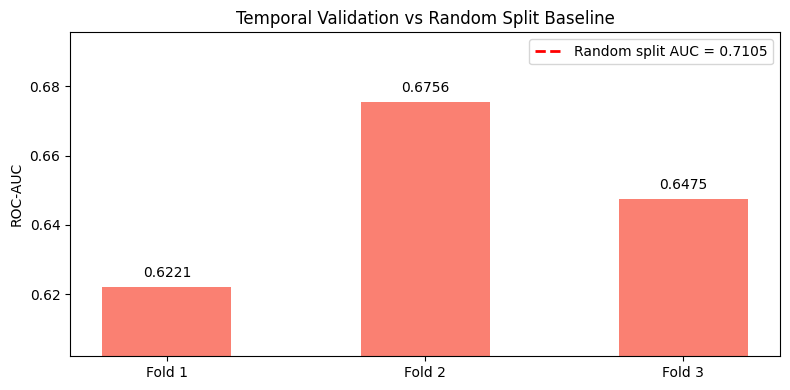

In [8]:
# Stability bar chart: temporal fold AUCs vs random split baseline
fig, ax = plt.subplots(figsize=(8, 4))

fold_labels = [f"Fold {k}" for k in range(1, N_FOLDS + 1)]
colors = ['steelblue' if a >= baseline_auc else 'salmon' for a in temporal_aucs]

ax.bar(fold_labels, temporal_aucs, color=colors, width=0.5)
ax.axhline(baseline_auc, color='red', linestyle='--', lw=2, label=f'Random split AUC = {baseline_auc:.4f}')
ax.set_ylim(min(temporal_aucs) - 0.02, max(temporal_aucs) + 0.02)
ax.set_ylabel('ROC-AUC')
ax.set_title('Temporal Validation vs Random Split Baseline')
ax.legend()

for i, auc in enumerate(temporal_aucs):
    ax.text(i, auc + 0.002, f'{auc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
fig.savefig(FIG_DIR / "05_temporal_auc.png", bbox_inches="tight", dpi=130)
plt.show()

## Interpretation

**What we measured**: Walk-forward temporal validation using IDpol as a time proxy.  Each fold trains on all earlier policies and tests on the next chronological block, mimicking real deployment conditions.

**Key findings**:
- If temporal AUCs ≈ random-split AUC → the model generalises well across time; the random split is trustworthy.
- If temporal AUCs < random-split AUC → **data leakage** or **temporal drift**; the random split over-estimates real performance.
- Variance across folds indicates model stability under distribution shift.

**Why IDpol works as a time proxy**: Policy IDs are typically assigned sequentially at enrollment. Earlier IDs represent older policies, which may have different risk profiles due to cohort effects (e.g., changes in underwriting criteria, economic conditions, vehicle fleet mix).

**In production**: Replace IDpol with an actual policy start date column for a more precise temporal split.